In [1]:
pip install ase

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy==1.24.4


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import io
import ase
import ase.calculators.calculator as ase_calc
import ase.io as ase_io
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation
from ase.md.verlet import VelocityVerlet
import ase.optimize as ase_opt
import matplotlib.pyplot as plt
#import py3Dmol
import e3x
import flax.linen as nn
import jax
import jax.numpy as jnp
from jax import random 
import flax 
import os 
import numpy as np 
import functools
import optax
import urllib.request

In [5]:
def mean_squared_loss(energy_prediction, energy_target, forces_prediction, forces_target, forces_weight):
  energy_loss = jnp.mean(optax.l2_loss(energy_prediction, energy_target))
  forces_loss = jnp.mean(optax.l2_loss(forces_prediction, forces_target))
  return energy_loss + forces_weight * forces_loss

def mean_absolute_error(prediction, target):
  return jnp.mean(jnp.abs(prediction - target))

In [6]:
# params not defined

In [7]:
### fffffff
# # --- MessagePassingModel definition ---
# class MessagePassingModel2(nn.Module):
#     features: int = 32
#     max_degree: int = 2
#     num_iterations: int = 1
#     num_basis_functions: int = 8
#     cutoff: float = 5.0
#     max_atomic_number: int = 118 

#     def energy(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
#         # 1. Compute displacement vectors.
#         positions_dst = e3x.ops.gather_dst(positions, dst_idx=dst_idx)
#         positions_src = e3x.ops.gather_src(positions, src_idx=src_idx)
#         displacements = positions_src - positions_dst

#         # 2. Expand in basis functions.
#         basis = e3x.nn.basis(
#             displacements,
#             num=self.num_basis_functions,
#             max_degree=self.max_degree,
#             radial_fn=e3x.nn.reciprocal_bernstein,
#             cutoff_fn=functools.partial(e3x.nn.smooth_cutoff, cutoff=self.cutoff)
#         )

#         # 3. Embed atomic numbers.
#         x = e3x.nn.Embed(num_embeddings=self.max_atomic_number+1, features=self.features)(atomic_numbers)

#         # 4. Message passing iterations.
#         for i in range(self.num_iterations):
#             if i == self.num_iterations-1:
#                 y = e3x.nn.MessagePass(max_degree=0, include_pseudotensors=False)(x, basis, dst_idx=dst_idx, src_idx=src_idx)
#                 x = e3x.nn.change_max_degree_or_type(x, max_degree=0, include_pseudotensors=False)
#             else:
#                 y = e3x.nn.MessagePass()(x, basis, dst_idx=dst_idx, src_idx=src_idx)
#                 y = e3x.nn.add(x, y)
#                 y = e3x.nn.Dense(self.features)(y)
#                 y = e3x.nn.silu(y)
#                 y = e3x.nn.Dense(self.features, kernel_init=jax.nn.initializers.zeros)(y)
#                 x = e3x.nn.add(x, y)

#         # 5. Predict atomic energies.
#         element_bias = self.param('element_bias', lambda rng, shape: jnp.zeros(shape), (self.max_atomic_number+1))
#         atomic_energies = nn.Dense(1, use_bias=False, kernel_init=jax.nn.initializers.zeros,  name="AAAAAAAAA")(x)
#         atomic_energies = jnp.squeeze(atomic_energies, axis=(-1, -2, -3))
#         # //////////////////////////////////////////////////////////////////////////////////////////////////////////
#         atomic_energies += element_bias[atomic_numbers] 
#         # print(element_bias[atomic_numbers])# //////////////////////////////////////////////////////////
#         # //////////////////////////////////////////////////////////////////////////////////////////////////////////
#         energy = jax.ops.segment_sum(atomic_energies, segment_ids=batch_segments, num_segments=batch_size)
#         return -jnp.sum(energy), energy

#     # This method extracts the molecule-level descriptor.
#     @nn.compact
#     def extract_descriptor(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
#         positions_dst = e3x.ops.gather_dst(positions, dst_idx=dst_idx)
#         positions_src = e3x.ops.gather_src(positions, src_idx=src_idx)
#         displacements = positions_src - positions_dst
#         basis = e3x.nn.basis(
#             displacements,
#             num=self.num_basis_functions,
#             max_degree=self.max_degree,
#             radial_fn=e3x.nn.reciprocal_bernstein,
#             cutoff_fn=functools.partial(e3x.nn.smooth_cutoff, cutoff=self.cutoff)
#         )
#         x = e3x.nn.Embed(num_embeddings=self.max_atomic_number+1, features=self.features)(atomic_numbers)
#         for i in range(self.num_iterations):
#             if i == self.num_iterations-1:
#                 y = e3x.nn.MessagePass(max_degree=0, include_pseudotensors=False)(x, basis, dst_idx=dst_idx, src_idx=src_idx)
#                 x = e3x.nn.change_max_degree_or_type(x, max_degree=0, include_pseudotensors=False)
#             else:
#                 y = e3x.nn.MessagePass()(x, basis, dst_idx=dst_idx, src_idx=src_idx)
#                 y = e3x.nn.add(x, y)
#                 y = e3x.nn.Dense(self.features)(y)
#                 y = e3x.nn.silu(y)
#                 y = e3x.nn.Dense(self.features, kernel_init=jax.nn.initializers.zeros)(y)
#                 x = e3x.nn.add(x, y)
#         # Aggregate atomic features to form a molecule-level descriptor.
#         descriptor = jax.ops.segment_sum(x, segment_ids=batch_segments, num_segments=batch_size)
#         return descriptor

#     # New method: extract descriptor and its gradient with respect to positions.
#     @nn.compact
#     def extract_descriptor_and_gradient(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
#         # Compute the descriptor.
#         descriptor = self.extract_descriptor(atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size)
#         # For calibration, assume batch_size == 1.
#         pos_shape = positions.shape  # (num_atoms, 3)
#         pos_flat = positions.reshape(-1)  # shape: (num_atoms*3,)
#         variables = self.scope.variables()
#         def desc_fn(pos_flat):
#             pos_reshaped = pos_flat.reshape(pos_shape)
#             mod = self  # capture instance
#             desc = mod.apply(
#                 variables,
#                 atomic_numbers,
#                 pos_reshaped,
#                 dst_idx,
#                 src_idx,
#                 batch_segments,
#                 batch_size,
#                 method=mod.extract_descriptor
#             )
#             return jnp.ravel(desc[0])  # return as 1D vector
#         # Use jax.vmap to compute the gradient for each descriptor component.
#         descriptor_dim = descriptor.shape[-1]
#         G = jax.vmap(lambda i: jax.grad(lambda x: desc_fn(x)[i])(pos_flat))(jnp.arange(descriptor_dim))
#         # G has shape (descriptor_dim, num_atoms*3)
#         return descriptor, G

#     @nn.compact
#     def __call__(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments=None, batch_size=None):
#         if batch_segments is None:
#             batch_segments = jnp.zeros_like(atomic_numbers)
#             batch_size = 1
#         energy_and_forces = jax.value_and_grad(self.energy, argnums=1, has_aux=True)
#         (_, energy), forces = energy_and_forces(atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size)


#         # ////////////////////////////////////////////////////////////////////////////////////////////////////////
#         # element_bias = self.param('element_bias', lambda rng, shape: jnp.zeros(shape), (self.max_atomic_number+1))
#         # energy += element_bias[atomic_numbers] 
#         return energy, forces


# @jax.jit
# def evaluate_energies_and_forces(atomic_numbers, positions, dst_idx, src_idx):
#   return MessagePassingModel.apply(params,
#     atomic_numbers=atomic_numbers,
#     positions=positions,
#     dst_idx=dst_idx,
#     src_idx=src_idx,
#   )


# class MessagePassingCalculator(ase_calc.Calculator):
#   implemented_properties = ["energy", "forces"]

#   def calculate(self, atoms, properties, system_changes = ase.calculators.calculator.all_changes):
#     ase_calc.Calculator.calculate(self, atoms, properties, system_changes)
#     dst_idx, src_idx = e3x.ops.sparse_pairwise_indices(len(atoms))
#     energy, forces = evaluate_energies_and_forces(
#       atomic_numbers=atoms.get_atomic_numbers(),
#       positions=atoms.get_positions(),
#       dst_idx=dst_idx,
#       src_idx=src_idx
#     )
#     self.results['energy'] = energy * ase.units.kcal/ase.units.mol
#     self.results['forces'] = forces * ase.units.kcal/ase.units.mol
    
    
# @functools.partial(jax.jit, static_argnames=('model_apply', 'optimizer_update', 'batch_size'))
# def train_step(model_apply, optimizer_update, batch, batch_size, forces_weight, opt_state, params):
#   def loss_fn(params):
#     energy, forces = model_apply(
#       params,
#       atomic_numbers=batch['atomic_numbers'],
#       positions=batch['positions'],
#       dst_idx=batch['dst_idx'],
#       src_idx=batch['src_idx'],
#       batch_segments=batch['batch_segments'],
#       batch_size=batch_size
#     )
#     loss = mean_squared_loss(
#       energy_prediction=energy,
#       energy_target=batch['energy'],
#       forces_prediction=forces,
#       forces_target=batch['forces'],
#       forces_weight=forces_weight
#     )
#     return loss, (energy, forces)
#   (loss, (energy, forces)), grad = jax.value_and_grad(loss_fn, has_aux=True)(params)
#   updates, opt_state = optimizer_update(grad, opt_state, params)
#   params = optax.apply_updates(params, updates)
#   energy_mae = mean_absolute_error(energy, batch['energy'])
#   forces_mae = mean_absolute_error(forces, batch['forces'])
#   return params, opt_state, loss, energy_mae, forces_mae


# @functools.partial(jax.jit, static_argnames=('model_apply', 'batch_size'))
# def eval_step(model_apply, batch, batch_size, forces_weight, params):
#   energy, forces = model_apply(
#     params,
#     atomic_numbers=batch['atomic_numbers'],
#     positions=batch['positions'],
#     dst_idx=batch['dst_idx'],
#     src_idx=batch['src_idx'],
#     batch_segments=batch['batch_segments'],
#     batch_size=batch_size
#   )
#   loss = mean_squared_loss(
#     energy_prediction=energy,
#     energy_target=batch['energy'],
#     forces_prediction=forces,
#     forces_target=batch['forces'],
#     forces_weight=forces_weight
#   )
#   energy_mae = mean_absolute_error(energy, batch['energy'])
#   forces_mae = mean_absolute_error(forces, batch['forces'])
#   return loss, energy_mae, forces_mae
    

In [8]:
# # --- MessagePassingModel definition ---
# class MessagePassingModel(nn.Module):
#     features: int = features
#     max_degree: int = max_degree
#     num_iterations: int = num_iterations
#     num_basis_functions: int = num_basis_functions
#     cutoff: float = cutoff
#     max_atomic_number: int = 118

#     def energy(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
#         # 1. Compute displacement vectors.
#         positions_dst = e3x.ops.gather_dst(positions, dst_idx=dst_idx)
#         positions_src = e3x.ops.gather_src(positions, src_idx=src_idx)
#         displacements = positions_src - positions_dst

#         # 2. Expand in basis functions.
#         basis = e3x.nn.basis(
#             displacements,
#             num=self.num_basis_functions,
#             max_degree=self.max_degree,
#             radial_fn=e3x.nn.reciprocal_bernstein,
#             cutoff_fn=functools.partial(e3x.nn.smooth_cutoff, cutoff=self.cutoff)
#         )

#         # 3. Embed atomic numbers.
#         x = e3x.nn.Embed(num_embeddings=self.max_atomic_number+1, features=self.features)(atomic_numbers)

#         # 4. Message passing iterations.
#         for i in range(self.num_iterations):
#             if i == self.num_iterations-1:
#                 y = e3x.nn.MessagePass(max_degree=0, include_pseudotensors=False)(x, basis, dst_idx=dst_idx, src_idx=src_idx)
#                 x = e3x.nn.change_max_degree_or_type(x, max_degree=0, include_pseudotensors=False)
#             else:
#                 y = e3x.nn.MessagePass()(x, basis, dst_idx=dst_idx, src_idx=src_idx)
#                 y = e3x.nn.add(x, y)
#                 y = e3x.nn.Dense(self.features)(y)
#                 y = e3x.nn.silu(y)
#                 y = e3x.nn.Dense(self.features, kernel_init=jax.nn.initializers.zeros)(y)
#                 x = e3x.nn.add(x, y)

#         # 5. Predict atomic energies.
#         element_bias = self.param('element_bias', lambda rng, shape: jnp.zeros(shape), (self.max_atomic_number+1))
#         atomic_energies = nn.Dense(1, use_bias=False, kernel_init=jax.nn.initializers.zeros, name="theta")(x)
#         atomic_energies = jnp.squeeze(atomic_energies, axis=(-1, -2, -3))
#         # //////////////////////////////////////////////////////////////////////////////////////////////////////////
#         atomic_energies += element_bias[atomic_numbers] 
#         # print(element_bias[atomic_numbers])# //////////////////////////////////////////////////////////
#         # //////////////////////////////////////////////////////////////////////////////////////////////////////////
#         energy = jax.ops.segment_sum(atomic_energies, segment_ids=batch_segments, num_segments=batch_size)
#         return -jnp.sum(energy), energy

#     # # This method extracts the molecule-level descriptor.
#     # @nn.compact
#     # def extract_descriptor(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
#     #     positions_dst = e3x.ops.gather_dst(positions, dst_idx=dst_idx)
#     #     positions_src = e3x.ops.gather_src(positions, src_idx=src_idx)
#     #     displacements = positions_src - positions_dst
#     #     basis = e3x.nn.basis(
#     #         displacements,
#     #         num=self.num_basis_functions,
#     #         max_degree=self.max_degree,
#     #         radial_fn=e3x.nn.reciprocal_bernstein,
#     #         cutoff_fn=functools.partial(e3x.nn.smooth_cutoff, cutoff=self.cutoff)
#     #     )
    #     x = e3x.nn.Embed(num_embeddings=self.max_atomic_number+1, features=self.features)(atomic_numbers)
    #     for i in range(self.num_iterations):
    #         if i == self.num_iterations-1:
    #             y = e3x.nn.MessagePass(max_degree=0, include_pseudotensors=False)(x, basis, dst_idx=dst_idx, src_idx=src_idx)
    #             x = e3x.nn.change_max_degree_or_type(x, max_degree=0, include_pseudotensors=False)
    #         else:
    #             y = e3x.nn.MessagePass()(x, basis, dst_idx=dst_idx, src_idx=src_idx)
    #             y = e3x.nn.add(x, y)
    #             y = e3x.nn.Dense(self.features)(y)
    #             y = e3x.nn.silu(y)
    #             y = e3x.nn.Dense(self.features, kernel_init=jax.nn.initializers.zeros)(y)
    #             x = e3x.nn.add(x, y)
    #     # Aggregate atomic features to form a molecule-level descriptor.
    #     descriptor = jax.ops.segment_sum(x, segment_ids=batch_segments, num_segments=batch_size)
    #     return descriptor

    # # New method: extract descriptor and its gradient with respect to positions.
    # @nn.compact
    # def extract_descriptor_and_gradient(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
    #     # Compute the descriptor.
    #     descriptor = self.extract_descriptor(atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size)
    #     # For calibration, assume batch_size == 1.
    #     pos_shape = positions.shape  # (num_atoms, 3)
    #     pos_flat = positions.reshape(-1)  # shape: (num_atoms*3,)
    #     variables = self.scope.variables()
    #     def desc_fn(pos_flat):
    #         pos_reshaped = pos_flat.reshape(pos_shape)
    #         mod = self  # capture instance
    #         desc = mod.apply(
    #             variables,
    #             atomic_numbers,
    #             pos_reshaped,
    #             dst_idx,
    #             src_idx,
    #             batch_segments,
    #             batch_size,
    #             method=mod.extract_descriptor
    #         )
    #         return jnp.ravel(desc[0])  # return as 1D vector
    #     # Use jax.vmap to compute the gradient for each descriptor component.
    #     descriptor_dim = descriptor.shape[-1]
    #     G = jax.vmap(lambda i: jax.grad(lambda x: desc_fn(x)[i])(pos_flat))(jnp.arange(descriptor_dim))
    #     # G has shape (descriptor_dim, num_atoms*3)
    #     return descriptor, G




In [9]:
class MessagePassingModel(nn.Module):
  features: int = 32
  max_degree: int = 2
  num_iterations: int = 3
  num_basis_functions: int = 8
  cutoff: float = 5.0
  max_atomic_number: int = 118  # This is overkill for most applications.


  def energy(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size):
    # 1. Calculate displacement vectors.
    positions_dst = e3x.ops.gather_dst(positions, dst_idx=dst_idx)
    positions_src = e3x.ops.gather_src(positions, src_idx=src_idx)
    displacements = positions_src - positions_dst  # Shape (num_pairs, 3).

    # 2. Expand displacement vectors in basis functions.
    basis = e3x.nn.basis(  # Shape (num_pairs, 1, (max_degree+1)**2, num_basis_functions).
      displacements,
      num=self.num_basis_functions,
      max_degree=self.max_degree,
      radial_fn=e3x.nn.reciprocal_bernstein,
      cutoff_fn=functools.partial(e3x.nn.smooth_cutoff, cutoff=self.cutoff)
    )

    # 3. Embed atomic numbers in feature space, x has shape (num_atoms, 1, 1, features).
    x = e3x.nn.Embed(num_embeddings=self.max_atomic_number+1, features=self.features)(atomic_numbers)

    # 4. Perform iterations (message-passing + atom-wise refinement).
    for i in range(self.num_iterations):
      # Message-pass.
      if i == self.num_iterations-1:  # Final iteration.
        # Since we will only use scalar features after the final message-pass, we do not want to produce non-scalar
        # features for efficiency reasons.
        y = e3x.nn.MessagePass(max_degree=0, include_pseudotensors=False)(x, basis, dst_idx=dst_idx, src_idx=src_idx)
        # After the final message pass, we can safely throw away all non-scalar features.
        x = e3x.nn.change_max_degree_or_type(x, max_degree=0, include_pseudotensors=False)
      else:
        # In intermediate iterations, the message-pass should consider all possible coupling paths.
        y = e3x.nn.MessagePass()(x, basis, dst_idx=dst_idx, src_idx=src_idx)
        y = e3x.nn.add(x, y)

        # Atom-wise refinement MLP.
        y = e3x.nn.Dense(self.features)(y)
        y = e3x.nn.silu(y)
        y = e3x.nn.Dense(self.features, kernel_init=jax.nn.initializers.zeros)(y)

        # Residual connection.
        x = e3x.nn.add(x, y)

    # 5. Predict atomic energies with an ordinary dense layer.
    element_bias = self.param('element_bias', lambda rng, shape: jnp.zeros(shape), (self.max_atomic_number+1))
    atomic_energies = nn.Dense(1, use_bias=False, kernel_init=jax.nn.initializers.zeros, name="theta")(x)  # (..., Natoms, 1, 1, 1)
    atomic_energies = jnp.squeeze(atomic_energies, axis=(-1, -2, -3))  # Squeeze last 3 dimensions.
    atomic_energies += element_bias[atomic_numbers]

    # 6. Sum atomic energies to obtain the total energy.
    energy = jax.ops.segment_sum(atomic_energies, segment_ids=batch_segments, num_segments=batch_size)

    # To be able to efficiently compute forces, our model should return a single output (instead of one for each
    # molecule in the batch). Fortunately, since all atomic contributions only influence the energy in their own
    # batch segment, we can simply sum the energy of all molecules in the batch to obtain a single proxy output
    # to differentiate.
    return -jnp.sum(energy), energy  # Forces are the negative gradient, hence the minus sign.


  @nn.compact
  def __call__(self, atomic_numbers, positions, dst_idx, src_idx, batch_segments=None, batch_size=None):
    if batch_segments is None:
      batch_segments = jnp.zeros_like(atomic_numbers)
      batch_size = 1

    # Since we want to also predict forces, i.e. the gradient of the energy w.r.t. positions (argument 1), we use
    # jax.value_and_grad to create a function for predicting both energy and forces for us.
    energy_and_forces = jax.value_and_grad(self.energy, argnums=1, has_aux=True)
    (_, energy), forces = energy_and_forces(atomic_numbers, positions, dst_idx, src_idx, batch_segments, batch_size)

    return energy, forces


@jax.jit
def evaluate_energies_and_forces(atomic_numbers, positions, dst_idx, src_idx, params):
  return MessagePassingModel.apply(params,
    atomic_numbers=atomic_numbers,
    positions=positions,
    dst_idx=dst_idx,
    src_idx=src_idx,
  )


class MessagePassingCalculator(ase_calc.Calculator):
  implemented_properties = ["energy", "forces"]

  def calculate(self, atoms, properties, system_changes = ase.calculators.calculator.all_changes):
    ase_calc.Calculator.calculate(self, atoms, properties, system_changes)
    dst_idx, src_idx = e3x.ops.sparse_pairwise_indices(len(atoms))
    energy, forces = evaluate_energies_and_forces(
      atomic_numbers=atoms.get_atomic_numbers(),
      positions=atoms.get_positions(),
      dst_idx=dst_idx,
      src_idx=src_idx
    )
    self.results['energy'] = energy * ase.units.kcal/ase.units.mol
    self.results['forces'] = forces * ase.units.kcal/ase.units.mol
    
    
@functools.partial(jax.jit, static_argnames=('model_apply', 'optimizer_update', 'batch_size'))
def train_step(model_apply, optimizer_update, batch, batch_size, forces_weight, opt_state, params):
  def loss_fn(params):
    energy, forces = model_apply(
      params,
      atomic_numbers=batch['atomic_numbers'],
      positions=batch['positions'],
      dst_idx=batch['dst_idx'],
      src_idx=batch['src_idx'],
      batch_segments=batch['batch_segments'],
      batch_size=batch_size
    )
    loss = mean_squared_loss(
      energy_prediction=energy,
      energy_target=batch['energy'],
      forces_prediction=forces,
      forces_target=batch['forces'],
      forces_weight=forces_weight
    )
    return loss, (energy, forces)
  (loss, (energy, forces)), grad = jax.value_and_grad(loss_fn, has_aux=True)(params)
  updates, opt_state = optimizer_update(grad, opt_state, params)
  params = optax.apply_updates(params, updates)
  energy_mae = mean_absolute_error(energy, batch['energy'])
  forces_mae = mean_absolute_error(forces, batch['forces'])
  return params, opt_state, loss, energy_mae, forces_mae


@functools.partial(jax.jit, static_argnames=('model_apply', 'batch_size'))
def eval_step(model_apply, batch, batch_size, forces_weight, params):
  energy, forces = model_apply(
    params,
    atomic_numbers=batch['atomic_numbers'],
    positions=batch['positions'],
    dst_idx=batch['dst_idx'],
    src_idx=batch['src_idx'],
    batch_segments=batch['batch_segments'],
    batch_size=batch_size
  )
  loss = mean_squared_loss(
    energy_prediction=energy,
    energy_target=batch['energy'],
    forces_prediction=forces,
    forces_target=batch['forces'],
    forces_weight=forces_weight
  )
  energy_mae = mean_absolute_error(energy, batch['energy'])
  forces_mae = mean_absolute_error(forces, batch['forces'])
  return loss, energy_mae, forces_mae
    

In [10]:

os.system('pwd')
os.system('ls -ltr')
# Model hyperparameters.
features = 32
max_degree = 1
num_iterations = 3
num_basis_functions = 32 #16
cutoff = 5.0
# Training hyperparameters.
num_train = 900
num_valid = 100

#Load the data: 
# Download the dataset.
filename = "md17_ethanol.npz"
if not os.path.exists(filename):
  print(f"Downloading {filename} (this may take a while)...")
  urllib.request.urlretrieve(f"http://www.quantum-machine.org/gdml/data/npz/{filename}", filename)
  
def prepare_datasets(key, num_train, num_valid):
  # Load the dataset.
  dataset = np.load(filename)

  # Make sure that the dataset contains enough entries.
  num_data = len(dataset['E'])
  num_draw = num_train + num_valid
  if num_draw > num_data:
    raise RuntimeError(
      f'datasets only contains {num_data} points, requested num_train={num_train}, num_valid={num_valid}')

  # Randomly draw train and validation sets from dataset.
  choice = np.asarray(jax.random.choice(key, num_data, shape=(num_draw,), replace=False))
  train_choice = choice[:num_train]
  valid_choice = choice[num_train:]

  # Determine mean energy of the training set.
  mean_energy = np.mean(dataset['E'][train_choice])  # ~ -97000

  # Collect and return train and validation sets.
  train_data = dict(
    energy=jnp.asarray(dataset['E'][train_choice, 0] - mean_energy),
    forces=jnp.asarray(dataset['F'][train_choice]),
    atomic_numbers=jnp.asarray(dataset['z']),
    positions=jnp.asarray(dataset['R'][train_choice]),
  )
  valid_data = dict(
    energy=jnp.asarray(dataset['E'][valid_choice, 0] - mean_energy),
    forces=jnp.asarray(dataset['F'][valid_choice]),
    atomic_numbers=jnp.asarray(dataset['z']),
    positions=jnp.asarray(dataset['R'][valid_choice]),
  )
  return train_data, valid_data, mean_energy

# Create PRNGKeys.
key = jax.random.PRNGKey(0)
data_key, train_key = jax.random.split(key, 2)

# Draw training and validation sets.
train_data, valid_data, _ = prepare_datasets(data_key, num_train=num_train, num_valid=num_valid)
  

In [11]:
pip install msgpack

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install msgpack_numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import flax
import msgpack
import msgpack_numpy
import pprint

# Use msgpack_numpy for proper NumPy serialization support
msgpack_numpy.patch()  # this allows msgpack to handle np arrays

# Load the .bin file as raw bytes
# with open("fisher_model_params.bin", "rb") as f:
# with open('Model/model_params.bin', 'rb') as f:
with open('before_model_params.bin', 'rb') as f:
    serialized_data = f.read()

# Decode it using Flax's internal tool
state_dict = flax.serialization.msgpack_restore(serialized_data)

# Pretty print the structure
pprint.pprint(state_dict)

{'params': {'Dense_0': {'0+': {'bias': array([-0.00777329, -0.00112266, -0.02043601, -0.03094166, -0.02500696,
       -0.008619  , -0.015396  , -0.06125629, -0.00945453, -0.04541123,
       -0.00429523, -0.00713976,  0.00066889,  0.0046918 , -0.00846436,
       -0.07597002,  0.01338194, -0.0097652 , -0.0529232 , -0.03139366,
       -0.06464132, -0.00901163,  0.03098079,  0.03586971,  0.01119309,
       -0.06138017, -0.01558992, -0.04826604,  0.0002274 , -0.00439048,
        0.00700488, -0.06215572], dtype=float32),
                               'kernel': array([[ 0.00646027,  0.13365218, -0.10619307, ..., -0.2298185 ,
         0.12989233,  0.18507041],
       [ 0.07864984, -0.23096456, -0.20251973, ..., -0.16121653,
         0.10811678,  0.02170964],
       [ 0.22748433, -0.07475602, -0.18691088, ...,  0.1599221 ,
         0.07867339,  0.11672007],
       ...,
       [-0.143567  ,  0.17097066,  0.15811385, ..., -0.05716717,
        -0.02765884, -0.09416548],
       [-0.00484637,  0.22

In [14]:
features = 32
max_degree = 2
num_iterations = 3
num_basis_functions = 32 #16
cutoff = 5.0

In [27]:

# Re-initialize the model exactly as you did before training
message_passing_model = MessagePassingModel(
    features=features,
    max_degree=max_degree,
    num_iterations=num_iterations,
    num_basis_functions=num_basis_functions,
    cutoff=cutoff,
)

# Create a PRNGKey for initialization
key = random.PRNGKey(0)  # Use a key, the specific value is not crucial here

# You don't need to provide dummy data for model structure initialization
# Instead, you only need to specify the PRNGKey
# This step is assuming the model's init doesn't explicitly require the input shapes at this stage
#dummy_params = reinitialized_model.init(key)
dst_idx, src_idx = e3x.ops.sparse_pairwise_indices(len(train_data['atomic_numbers']))
atomic_numbers=train_data['atomic_numbers']
positions=train_data['positions'][0]
# print("ok")


dummy_params = message_passing_model.init(key, atomic_numbers=atomic_numbers, positions=positions, dst_idx=dst_idx, src_idx=src_idx)
# with open('Model/model_params.bin', 'rb') as f:
with open('before_model_params.bin', 'rb') as f:


# import flax
# from flax.serialization import msgpack_restore
# # Load raw state dict
# # state_dict = msgpack_restore(serialized_params)
# # Compare structure
# from flax.traverse_util import flatten_dict
# print("Expected model param keys:")
# for key in flatten_dict(dummy_params).keys():
#     print(key)

# with open('bare_model_params.bin', 'rb') as f:
     serialized_params = f.read()

print("ko")
default_params = flax.serialization.from_bytes(dummy_params, serialized_params)  
# print(params)  


with open('fisher_model_params.bin', 'rb') as f:
    fisher_serialized_params = f.read()

params = flax.serialization.from_bytes(dummy_params, fisher_serialized_params)  
# print(params)

ko


In [28]:
import pprint
def print_shape_structure(d):
    for key, value in d.items():
        if isinstance(value, np.ndarray):
            print(f"Shape of '{key}': {value.shape}")
        elif isinstance(value, dict):  # If it's a nested dictionary, recurse
            print(f"Nested dictionary '{key}':")
            print_shape_structure(value)


In [33]:

#@jax.jit
def evaluate_energies_and_forces(atomic_numbers, positions, dst_idx, src_idx):
  return message_passing_model.apply(params,
    atomic_numbers=jax.numpy.array(atomic_numbers),
    positions= jax.numpy.array(positions),
    dst_idx=jax.numpy.array(dst_idx),
    src_idx=jax.numpy.array(src_idx),
  )

###def evaluate_energies_and_forces(atomic_numbers, positions, dst_idx, src_idx):
###    # Convert inputs to JAX arrays if they aren't already
###    atomic_numbers_jax = jax.numpy.array(atomic_numbers)
###    positions_jax = jax.numpy.array(positions)
###    dst_idx_jax = jax.numpy.array(dst_idx)
###    src_idx_jax = jax.numpy.array(src_idx)
###
###    # JIT-compiled inner function
###    @jax.jit
###    def compute(atomic_numbers, positions, dst_idx, src_idx):
###        return message_passing_model.apply(params,
###            atomic_numbers=atomic_numbers,
###            positions=positions,
###            dst_idx=dst_idx,
###            src_idx=src_idx,
###        )
###
###    # Call the JIT-compiled function
###    energy, forces = compute(atomic_numbers_jax, positions_jax, dst_idx_jax, src_idx_jax)
###
###    # Ensure explicit conversion from JAX arrays to NumPy arrays
###    return energy.block_until_ready().to_numpy(), forces.block_until_ready().to_numpy()
 


class MessagePassingCalculator(ase_calc.Calculator):
  implemented_properties = ["energy", "forces"]

  def calculate(self, atoms, properties, system_changes = ase.calculators.calculator.all_changes):
    
    ase_calc.Calculator.calculate(self, atoms, properties, system_changes)
    
    dst_idx, src_idx = e3x.ops.sparse_pairwise_indices(len(atoms))
    #print("ok")
    energy, forces = evaluate_energies_and_forces(
      atomic_numbers=atoms.get_atomic_numbers(),
      positions=atoms.get_positions(),
      dst_idx=dst_idx,
      src_idx=src_idx
    )
    
    # Assuming energy and forces are initially JAX arrays and forces is correctly shaped as [num_atoms, 3]
    energy_np = np.array(energy.block_until_ready()).item()  # Convert to Python scalar
    forces_np = np.array(forces.block_until_ready())  # Ensure this is a 2D NumPy array, [num_atoms, 3]

    self.results['energy'] = energy_np * ase.units.kcal/ase.units.mol
    self.results['forces'] = forces_np * ase.units.kcal/ase.units.mol

# Initialize atoms object and attach calculator.
atoms = ase.Atoms(train_data['atomic_numbers'], train_data['positions'][0])
atoms.set_calculator(MessagePassingCalculator())

# Run structure optimization with BFGS.
_ = ase_opt.BFGS(atoms).run(fmax=0.05)

      Step     Time          Energy         fmax
BFGS:    0 20:51:26        2.892060        0.3057
BFGS:    1 20:51:27        2.887983        0.2989
BFGS:    2 20:51:28        2.814960        0.4103
BFGS:    3 20:51:30        2.810122        0.3863
BFGS:    4 20:51:32        2.698666        0.3334
BFGS:    5 20:51:33        2.690645        0.4278
BFGS:    6 20:51:34        2.679832        0.3885
BFGS:    7 20:51:36        2.649283        0.3804
BFGS:    8 20:51:38        2.621778        0.3874
BFGS:    9 20:51:39        2.512036        0.3759
BFGS:   10 20:51:41        2.501650        0.7373
BFGS:   11 20:51:42        2.480957        0.4114
BFGS:   12 20:51:43        2.473921        0.4103
BFGS:   13 20:51:45        2.409311        0.8473
BFGS:   14 20:51:47        2.192454        3.9418
BFGS:   15 20:51:48        0.755698        7.6120
BFGS:   16 20:51:49        1.633002        7.2521
BFGS:   17 20:51:50        0.735647        5.1474
BFGS:   18 20:51:52        0.894326        9.0964
B

In [34]:
#vizu# # Write structure to xyz file.
#vizu# xyz = io.StringIO()
#vizu# ase_io.write(xyz, atoms, format='xyz')
#vizu# 
#vizu# # Visualize the structure with py3Dmol.
#vizu# view = py3Dmol.view()
#vizu# view.addModel(xyz.getvalue(), 'xyz')
#vizu# view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.25}})
#vizu# view.show()

In [35]:
# Parameters.
temperature = 1000
timestep_fs = 1.0
num_steps = 400

# Draw initial momenta.
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature)
Stationary(atoms)  # Remove center of mass translation.
ZeroRotation(atoms)  # Remove rotations.

# Initialize Velocity Verlet integrator.
integrator = VelocityVerlet(atoms, timestep=timestep_fs*ase.units.fs)

# Run molecular dynamics.
frames = np.zeros((num_steps, len(atoms), 3))
potential_energy = np.zeros((num_steps,))
kinetic_energy = np.zeros((num_steps,))
total_energy = np.zeros((num_steps,))
for i in range(num_steps):
  # Run 1 time step.
  integrator.run(1)
  # Save current frame and keep track of energies.
  frames[i] = atoms.get_positions()
  potential_energy[i] = atoms.get_potential_energy()
  kinetic_energy[i] = atoms.get_kinetic_energy()
  total_energy[i] = atoms.get_total_energy()
  # Occasionally print progress.
  if i % 40 == 0:
    print(f"step {i:5d} epot {potential_energy[i]: 5.3f} ekin {kinetic_energy[i]: 5.3f} etot {total_energy[i]: 5.3f}")


step     0 epot -0.481 ekin  0.675 etot  0.193
step    40 epot -0.180 ekin  0.389 etot  0.209
step    80 epot -0.393 ekin  0.554 etot  0.161
step   120 epot  0.224 ekin  26.993 etot  27.216
step   160 epot -0.528 ekin  28.046 etot  27.518
step   200 epot -1.086 ekin  27.752 etot  26.666
step   240 epot -1.091 ekin  27.955 etot  26.863
step   280 epot  0.152 ekin  28.895 etot  29.048
step   320 epot  0.671 ekin  29.287 etot  29.958
step   360 epot  0.910 ekin  29.060 etot  29.970


In [36]:
#vizu# view.getModel().setCoordinates(frames, 'array')
#vizu# view.animate({'loop': 'forward', 'interval': 0.1})
#vizu# view.show()

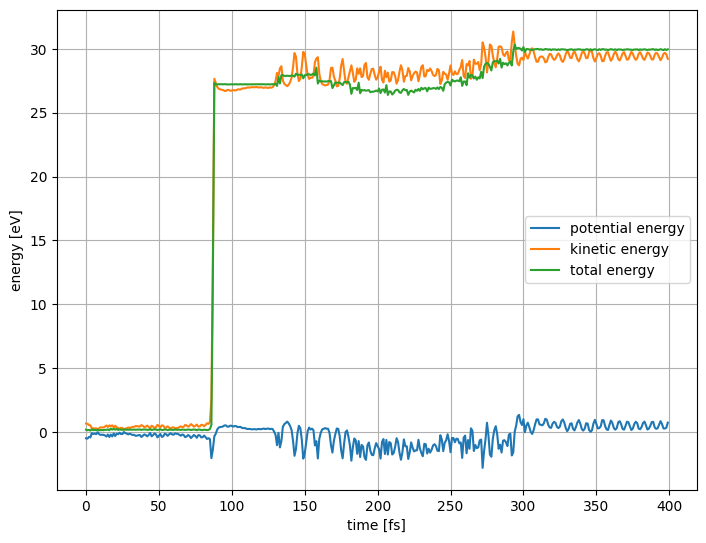

In [37]:
%matplotlib inline
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.xlabel('time [fs]')
plt.ylabel('energy [eV]')
time = np.arange(num_steps) * timestep_fs
plt.plot(time, potential_energy, label='potential energy')
plt.plot(time, kinetic_energy, label='kinetic energy')
plt.plot(time, total_energy, label='total energy')
plt.legend()
plt.grid()

In [38]:
!jupyter nbconvert --to html run.ipynb

[NbConvertApp] Converting notebook run.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 508766 bytes to run.html
